In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV, LassoCV

In [2]:
df = pd.read_csv('Air_Traffic_Passenger_Statistics.csv',encoding='latin-1')
df.head()
df.shape
df.columns
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15007 entries, 0 to 15006
Data columns (total 16 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Activity Period              15007 non-null  int64 
 1   Operating Airline            15007 non-null  object
 2   Operating Airline IATA Code  14953 non-null  object
 3   Published Airline            15007 non-null  object
 4   Published Airline IATA Code  14953 non-null  object
 5   GEO Summary                  15007 non-null  object
 6   GEO Region                   15007 non-null  object
 7   Activity Type Code           15007 non-null  object
 8   Price Category Code          15007 non-null  object
 9   Terminal                     15007 non-null  object
 10  Boarding Area                15007 non-null  object
 11  Passenger Count              15007 non-null  int64 
 12  Adjusted Activity Type Code  15007 non-null  object
 13  Adjusted Passenger Count     15

,Activity Period,Passenger Count,Adjusted Passenger Count,Year
count,15007.000000,15007.000000,15007.000000,15007.000000
mean,201045.073366,29240.521090,29331.917105,2010.385220
std,313.336196,58319.509284,58284.182219,3.137589
min,200507.000000,1.000000,1.000000,2005.000000
25%,200803.000000,5373.500000,5495.500000,2008.000000
50%,201011.000000,9210.000000,9354.000000,2010.000000
75%,201308.000000,21158.500000,21182.000000,2013.000000
max,201603.000000,659837.000000,659837.000000,2016.000000


In [3]:
df.isnull().sum()

Activity Period                 0
Operating Airline               0
Operating Airline IATA Code    54
Published Airline               0
Published Airline IATA Code    54
GEO Summary                     0
GEO Region                      0
Activity Type Code              0
Price Category Code             0
Terminal                        0
Boarding Area                   0
Passenger Count                 0
Adjusted Activity Type Code     0
Adjusted Passenger Count        0
Year                            0
Month                           0
dtype: int64

In [4]:
[features for features in df.columns if df[features].isnull().sum()>0]

['Operating Airline IATA Code', 'Published Airline IATA Code']

<Axes: >

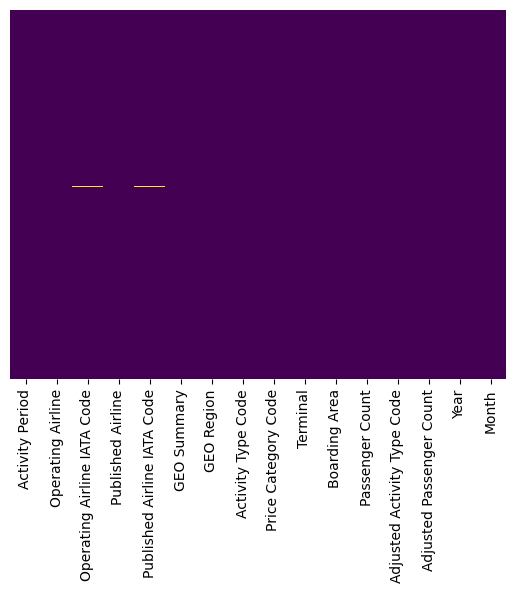

In [5]:
sns.heatmap(df.isnull(),yticklabels=False,cbar=False,cmap='viridis')

In [6]:
#Handling missing values on Operating Airline IATA Code and Published Airline IATA Code
df[
    df['Operating Airline IATA Code'].isnull() &
    df['Published Airline IATA Code'].isnull()
].shape
df['Operating Airline IATA Code'] = df['Operating Airline IATA Code'].fillna('unknown')
df['Published Airline IATA Code'] = df['Published Airline IATA Code'].fillna('unknown')
df['Operating Airline IATA Code'].value_counts().to_string()
(df['Operating Airline IATA Code'] == '').sum()
df['Operating Airline IATA Code'].str.strip().eq('').sum()
df['Operating Airline IATA Code'].unique()
df['Published Airline IATA Code'].unique()
df = df.drop(['Passenger Count','Activity Period'], axis =1)
df.duplicated().sum()

np.int64(0)

In [7]:
#univariate analysis for Passenger count column
df['Adjusted Passenger Count'].describe()

count     15007.000000
mean      29331.917105
std       58284.182219
min           1.000000
25%        5495.500000
50%        9354.000000
75%       21182.000000
max      659837.000000
Name: Adjusted Passenger Count, dtype: float64

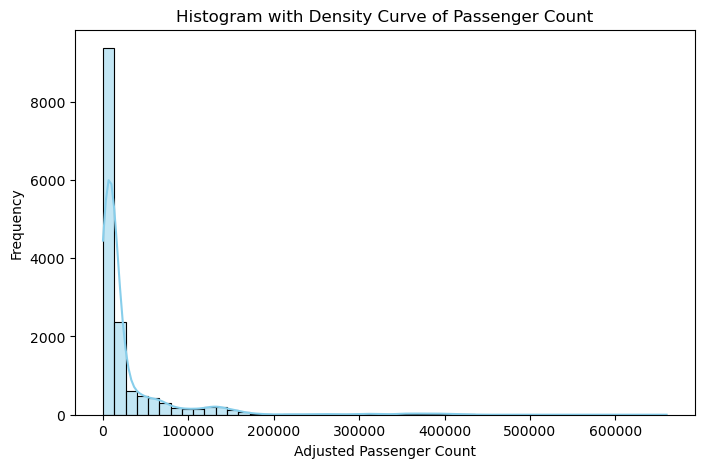

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(df['Adjusted Passenger Count'],bins=50,kde=True,color='skyblue')
plt.title('Histogram with Density Curve of Passenger Count')
plt.xlabel('Adjusted Passenger Count')
plt.ylabel('Frequency')
plt.show()

In [9]:
#Handle Outliers
def detect_outliers(data):
    outliers=[]
    threshold = 3
    mean = np.mean(data)
    std = np.std(data)
    for i in data:
        z_score = (i-mean)/std
        if np.abs(z_score)>threshold:
            outliers.append(i)
    return outliers

In [10]:
outliers_pt=detect_outliers(df['Adjusted Passenger Count'])
outliers_pt
len(outliers_pt)

322

In [11]:
len(df['Adjusted Passenger Count'])

15007

In [12]:
#Perform InterQuartilerange
df['Adjusted Passenger Count'].sort_values()

3501          1
1865          1
1864          1
4218          1
13046         2
          ...  
11566    573619
11219    622871
11218    625885
11332    629003
11331    659837
Name: Adjusted Passenger Count, Length: 15007, dtype: int64

In [13]:
Q1 = df['Adjusted Passenger Count'].quantile(0.25)
Q3 = df['Adjusted Passenger Count'].quantile(0.75)
print('Q1:', Q1)
print('Q3:', Q3)

Q1: 5495.5
Q3: 21182.0


In [14]:
#Calculate IQR
IQR = Q3-Q1
print('Q3:', Q3)

Q3: 21182.0


In [15]:
#defining upper and lower bound
lower_bound = Q1-1.5*IQR
upper_bound = Q3+1.5*IQR
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Lower Bound: -18034.25
Upper Bound: 44711.75


In [16]:
outliers = df[(df['Adjusted Passenger Count'] < lower_bound) | 
              (df['Adjusted Passenger Count'] > upper_bound)]

print("Number of Outliers:", outliers.shape[0])



Number of Outliers: 2435


In [17]:
outlier_percentage = (outliers.shape[0] / df.shape[0]) * 100
print(outlier_percentage)

16.225761311388016


In [18]:
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 5495.5
Q3: 21182.0
IQR: 15686.5
Lower Bound: -18034.25
Upper Bound: 44711.75


In [19]:
#log outlier data(Detected outliers and decided not to remove them)
df['Passenger_Count_log'] = np.log1p(df['Adjusted Passenger Count'])

In [20]:
print("Original Skew:", df['Adjusted Passenger Count'].skew())
print("Log Skew:", df['Passenger_Count_log'].skew())

Original Skew: 4.364715423638575
Log Skew: -0.750435187918804


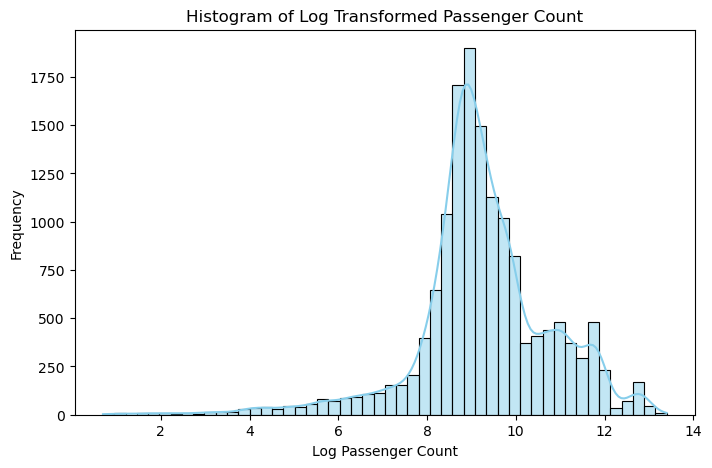

In [21]:
#Univariate analysis after the outlier handling to check the skewness
plt.figure(figsize=(8,5))
sns.histplot(df['Passenger_Count_log'], bins=50, kde=True, color='skyblue')
plt.title('Histogram of Log Transformed Passenger Count')
plt.xlabel('Log Passenger Count')
plt.ylabel('Frequency')
plt.show()

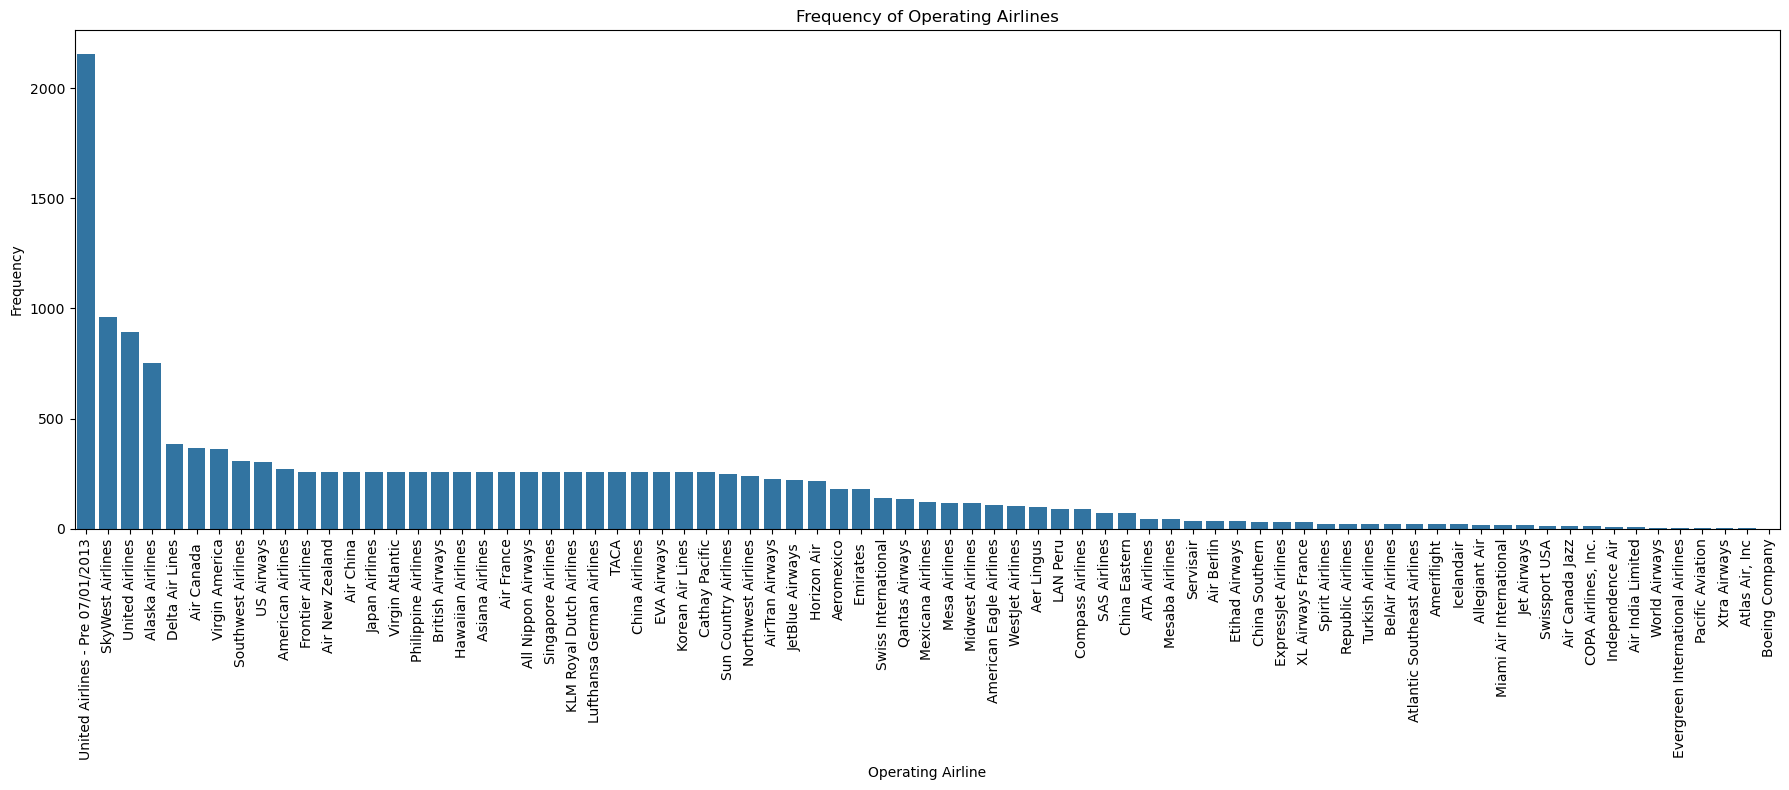

In [22]:
#Univariate analysis for  Operating airlines
plt.figure(figsize=(18,8))

sns.countplot(x='Operating Airline',data=df,order=df['Operating Airline'].value_counts().index)
plt.xticks(rotation=90)
plt.title('Frequency of Operating Airlines')
plt.xlabel('Operating Airline')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

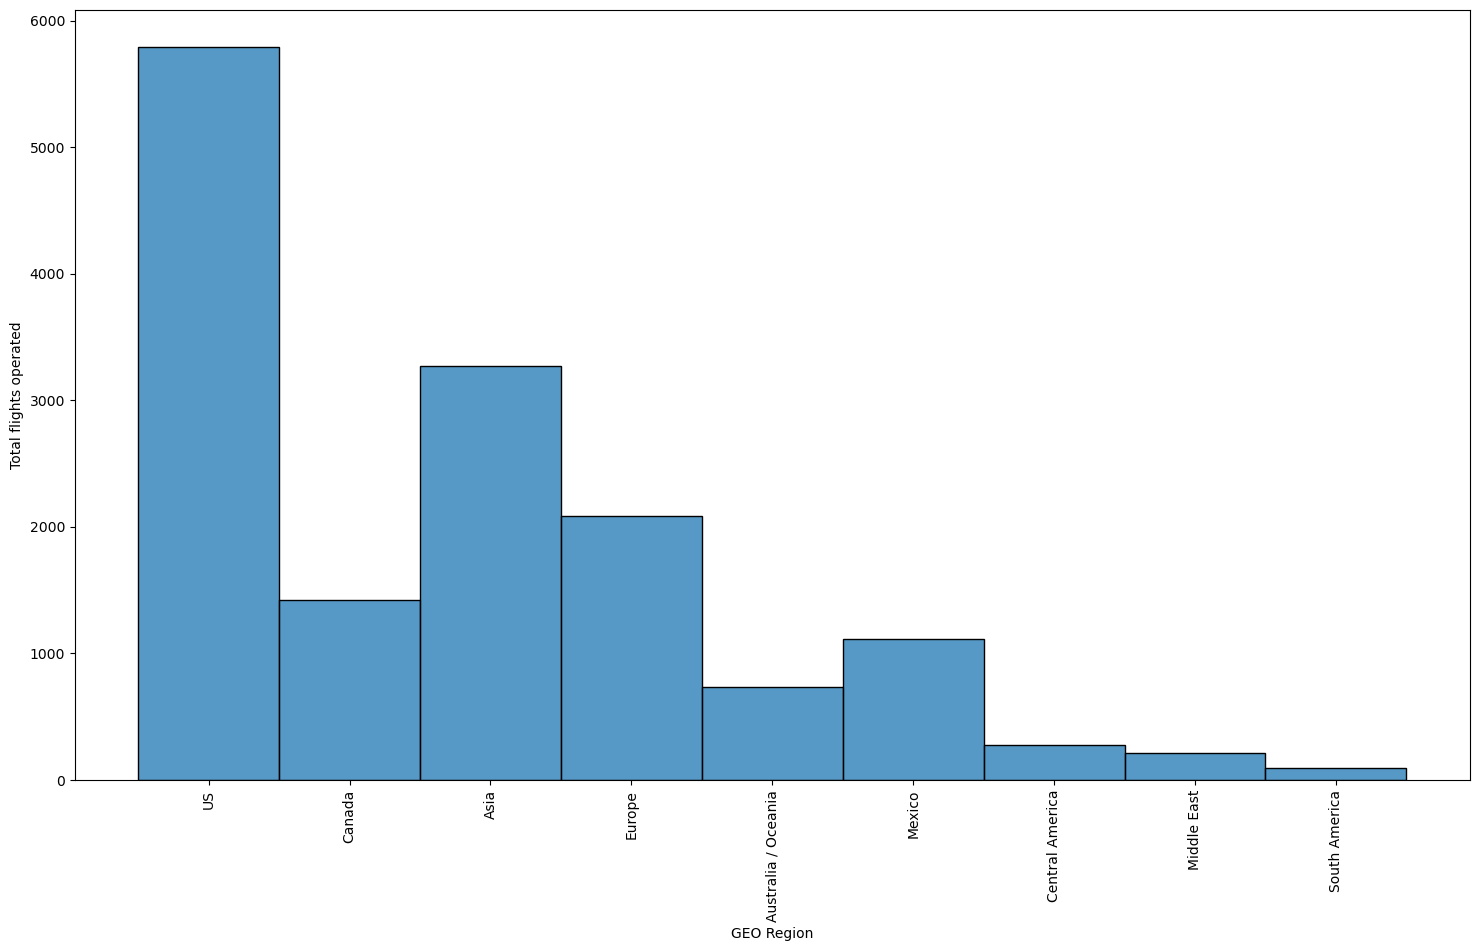

In [23]:
#Univarate analysis for GEO Region
plt.figure(figsize = (18,10))
sns.histplot(x='GEO Region', data=df)
plt.xticks(rotation = 90)
plt.ylabel("Total flights operated")
plt.show()


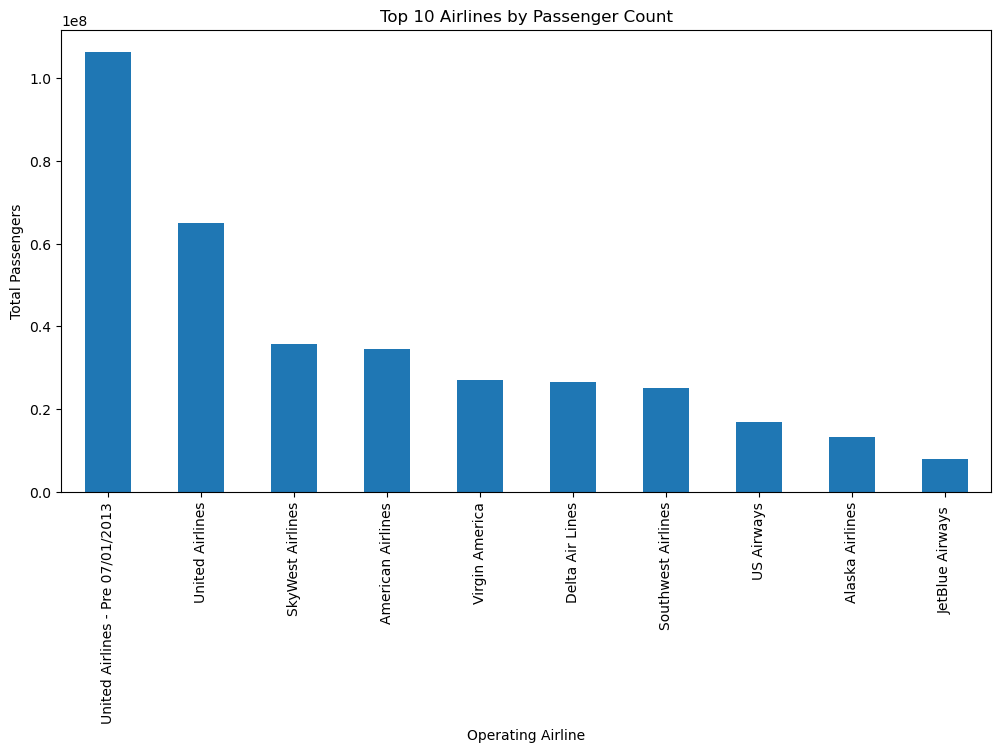

In [24]:
#Bivariate analysis for Operating airlines and Passenger count
plt.figure(figsize=(12,6))
df.groupby('Operating Airline')['Adjusted Passenger Count'].sum().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top 10 Airlines by Passenger Count")
plt.ylabel("Total Passengers")
plt.show()

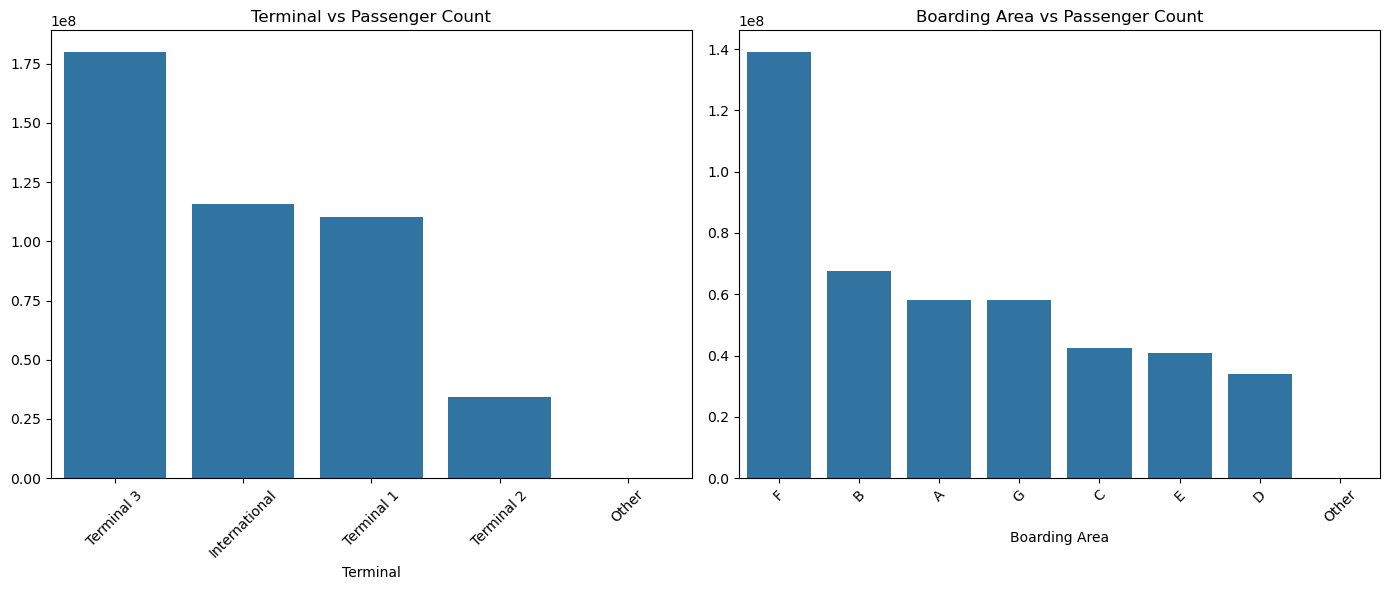

In [25]:
#Bivariate analysis for Passengers across Terminals and Gates
terminal_stats = df.groupby("Terminal")["Adjusted Passenger Count"].sum().sort_values(ascending=False)
gate_stats = df.groupby("Boarding Area")["Adjusted Passenger Count"].sum().sort_values(ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(14,6))
# Plot 1: Terminal vs Passenger Count
sns.barplot(x=terminal_stats.index, y=terminal_stats.values, ax=axes[0])
axes[0].set_title("Terminal vs Passenger Count")
axes[0].tick_params(axis='x', rotation=45)
# Plot 2: Boarding Area vs Passenger Count
sns.barplot(x=gate_stats.index, y=gate_stats.values, ax=axes[1])
axes[1].set_title("Boarding Area vs Passenger Count")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

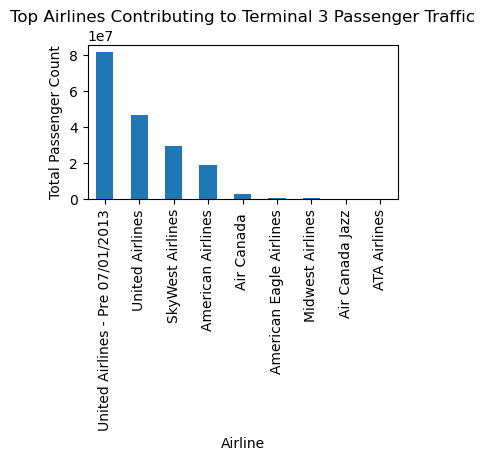

In [26]:
terminal3_airlines = df[df['Terminal'] == 'Terminal 3']

terminal3_summary = terminal3_airlines.groupby('Operating Airline')['Adjusted Passenger Count'].sum().sort_values(ascending=False)

terminal3_summary.head(10)
terminal3_summary.head(10).plot(kind='bar', figsize=(4,2))
plt.title("Top Airlines Contributing to Terminal 3 Passenger Traffic")
plt.xlabel("Airline")
plt.ylabel("Total Passenger Count")
plt.xticks(rotation=90)
plt.show()


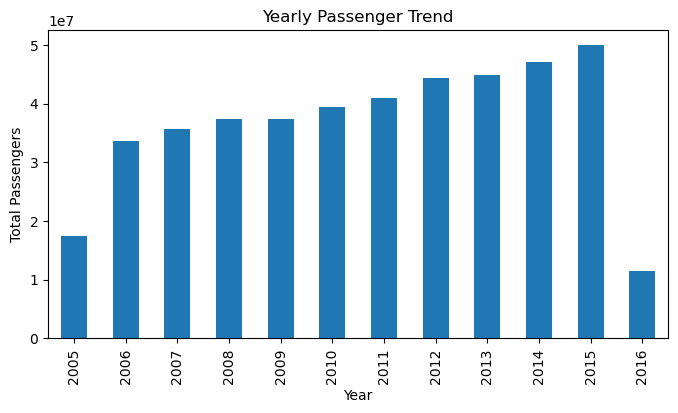

In [27]:
#Bivariate analysis for Year vs Passenger Count
yearly = df.groupby('Year')['Adjusted Passenger Count'].sum()

plt.figure(figsize=(8,4))
yearly.plot(kind='bar')
plt.title("Yearly Passenger Trend")
plt.ylabel("Total Passengers")
plt.show()

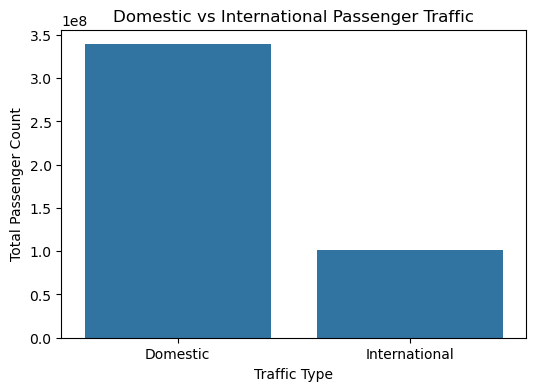

In [28]:
#Bivariate analysis on Domestic vs International Traffic
geo_total = df.groupby('GEO Summary')['Adjusted Passenger Count'].sum().reset_index()

plt.figure(figsize=(6,4))
sns.barplot(x='GEO Summary', y='Adjusted Passenger Count', data=geo_total)
plt.title("Domestic vs International Passenger Traffic")
plt.ylabel("Total Passenger Count")
plt.xlabel("Traffic Type")
plt.show()

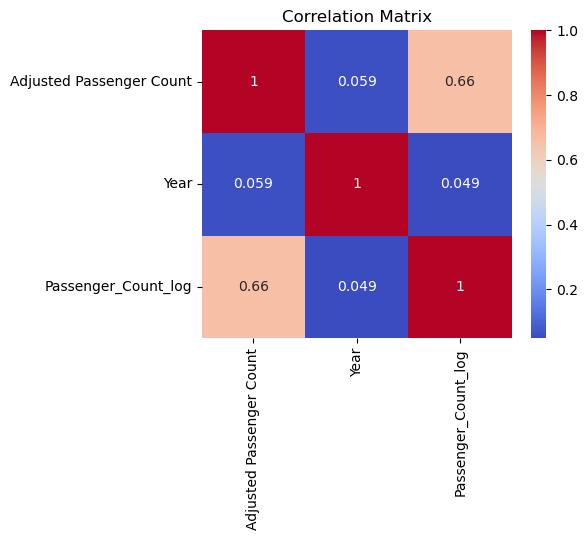

In [29]:
#Correlation analysis
numeric_df = df.select_dtypes(include='number')
numeric_df.head()
corr = numeric_df.corr()
plt.figure(figsize=(5,4))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [30]:
numeric_df.columns

Index(['Adjusted Passenger Count', 'Year', 'Passenger_Count_log'], dtype='object')

In [31]:
df.columns

Index(['Operating Airline', 'Operating Airline IATA Code', 'Published Airline',
       'Published Airline IATA Code', 'GEO Summary', 'GEO Region',
       'Activity Type Code', 'Price Category Code', 'Terminal',
       'Boarding Area', 'Adjusted Activity Type Code',
       'Adjusted Passenger Count', 'Year', 'Month', 'Passenger_Count_log'],
      dtype='object')

In [32]:
df['Month'] = pd.to_datetime(df['Month'], format='%B').dt.month
df.columns


Index(['Operating Airline', 'Operating Airline IATA Code', 'Published Airline',
       'Published Airline IATA Code', 'GEO Summary', 'GEO Region',
       'Activity Type Code', 'Price Category Code', 'Terminal',
       'Boarding Area', 'Adjusted Activity Type Code',
       'Adjusted Passenger Count', 'Year', 'Month', 'Passenger_Count_log'],
      dtype='object')

In [33]:
drop_cols = [
    'Operating Airline',
    'Published Airline',
    'Operating Airline IATA Code',
    'Published Airline IATA Code',
    'Passenger_Count_log',
    'Adjusted Activity Type Code'
]
df_base = df.drop(columns=drop_cols)
train_idx, test_idx = train_test_split(
    df_base.index, test_size=0.2, random_state=42
)
#Base dataset
X_base = df_base.drop('Adjusted Passenger Count', axis=1)
y = df_base['Adjusted Passenger Count']

X_train_base = X_base.loc[train_idx]
X_test_base = X_base.loc[test_idx]
y_train = y.loc[train_idx]
y_test = y.loc[test_idx]

In [34]:
#Feature Engineering
df_fe = df_base.copy()
df_fe['Year'] = df_fe['Year'] - df_fe['Year'].min()

df_fe['Month_sin'] = np.sin(2 * np.pi * df_fe['Month'] / 12)
df_fe['Month_cos'] = np.cos(2 * np.pi * df_fe['Month'] / 12)

df_fe['Quarter'] = (df_fe['Month'] - 1) // 3 + 1
df_fe['Is_Peak'] = df_fe['Month'].isin([5,6,7,11,12]).astype(int)
df_fe['Year_Month_Interaction'] = df_fe['Year'] * df_fe['Month_sin']
df_fe['Log_Year'] = np.log1p(df_fe['Year'])
df_fe = df_fe.drop('Month', axis=1)
df_fe['Geo_Price'] = df_fe['GEO Region'] + "_" + df_fe['Price Category Code']
num_cols = ['Year', 'Month_sin', 'Month_cos', 'Year_Month_Interaction', 'Log_Year']


In [35]:
#Split FE dataset
X_fe = df_fe.drop('Adjusted Passenger Count', axis=1)
X_train_fe = X_fe.loc[train_idx]
X_test_fe = X_fe.loc[test_idx]

In [36]:
#Encoding
cat_cols_base = X_train_base.select_dtypes(include='object').columns
cat_cols_fe = X_train_fe.select_dtypes(include='object').columns

# Base dataset
X_train_base = pd.get_dummies(X_train_base, columns=cat_cols_base, drop_first=True)
X_test_base = pd.get_dummies(X_test_base, columns=cat_cols_base, drop_first=True)

# Feature Engineered dataset
X_train_fe = pd.get_dummies(X_train_fe, columns=cat_cols_fe, drop_first=True)
X_test_fe = pd.get_dummies(X_test_fe, columns=cat_cols_fe, drop_first=True)
scaler = StandardScaler()
X_train_fe[num_cols] = scaler.fit_transform(X_train_fe[num_cols])
X_test_fe[num_cols] = scaler.transform(X_test_fe[num_cols])
# Base
X_train_base, X_test_base = X_train_base.align(
    X_test_base, join='left', axis=1, fill_value=0
)
# FE
X_train_fe, X_test_fe = X_train_fe.align(
    X_test_fe, join='left', axis=1, fill_value=0
)

In [37]:
#Train Models
# Base model
model_base = LinearRegression()
model_base.fit(X_train_base, y_train)
# Feature engineered model
model_fe = LinearRegression()
model_fe.fit(X_train_fe, y_train)
# Base predictions
y_pred_base = model_base.predict(X_test_base)
y_pred_fe = model_fe.predict(X_test_fe)
#Evaluation
mae_base = mean_absolute_error(y_test, y_pred_base)
rmse_base = np.sqrt(mean_squared_error(y_test, y_pred_base))
r2_base = r2_score(y_test, y_pred_base)

mae_fe = mean_absolute_error(y_test, y_pred_fe)
rmse_fe = np.sqrt(mean_squared_error(y_test, y_pred_fe))
r2_fe = r2_score(y_test, y_pred_fe)

print("----- BASE MODEL -----")
print("MAE:", mae_base)
print("RMSE:", rmse_base)
print("R2:", r2_base)

print("\n----- FEATURE ENGINEERED MODEL -----")
print("MAE:", mae_fe)
print("RMSE:", rmse_fe)
print("R2:", r2_fe)

----- BASE MODEL -----
MAE: 25893.924918835615
RMSE: 44749.15688448804
R2: 0.3833631466583709

----- FEATURE ENGINEERED MODEL -----
MAE: 25965.147867094147
RMSE: 44593.02447821046
R2: 0.3876586035737296


In [38]:
#Manual Matrix Prediction
# numeric
X_train_base = X_train_base.astype(float)
X_test_base = X_test_base.astype(float)

# Convert to matrix
X_mat = X_train_base.values
y_mat = y_train.values.reshape(-1, 1)
X_test_mat = X_test_base.values

# Adding intercept
X_mat = np.c_[np.ones((X_mat.shape[0], 1)), X_mat]
X_test_mat = np.c_[np.ones((X_test_mat.shape[0], 1)), X_test_mat]

# Pseudo-inverse (precision technique)
beta = np.linalg.pinv(X_mat) @ y_mat
y_pred_manual = (X_test_mat @ beta).flatten()

mae_manual = mean_absolute_error(y_test, y_pred_manual)
rmse_manual = np.sqrt(mean_squared_error(y_test, y_pred_manual))
r2_manual = r2_score(y_test, y_pred_manual)

print("\n----- MANUAL MATRIX MODEL -----")
print("MAE:", mae_manual)
print("RMSE:", rmse_manual)
print("R2:", r2_manual)


----- MANUAL MATRIX MODEL -----
MAE: 25893.924918838347
RMSE: 44749.156884487544
R2: 0.38336314665838456


In [39]:
#Coefficient Interpretaion
feature_names = ['Intercept'] + list(X_train_base.columns)

coeff_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': beta.flatten()
})

print("\nTop Positive Features:")
print(coeff_df.sort_values(by='Coefficient', ascending=False).head(10))


Top Positive Features:
                      Feature   Coefficient
23            Boarding Area_F  55087.920987
18        Terminal_Terminal 3  38776.209924
21            Boarding Area_D  33252.015524
17        Terminal_Terminal 2  33252.015524
19            Boarding Area_B  22908.108106
14  Price Category Code_Other  12760.408236
20            Boarding Area_C  10407.345742
24            Boarding Area_G   9433.157162
1                        Year    988.004153
2                       Month    388.219793


In [40]:
print("\n----- FINAL COMPARISON -----")
print("Base R2:", r2_base)
print("FE R2:", r2_fe)
print("Manual R2:", r2_manual)

print("\nDifference (Sklearn vs Manual):", abs(r2_base - r2_manual))


----- FINAL COMPARISON -----
Base R2: 0.3833631466583709
FE R2: 0.3876586035737296
Manual R2: 0.38336314665838456

Difference (Sklearn vs Manual): 1.3655743202889425e-14


In [41]:
#Logictic Regression
# Creating binary target
threshold = df_base['Adjusted Passenger Count'].median()
df_base['High_Traffic'] = (df_base['Adjusted Passenger Count'] > threshold).astype(int)
df_fe['High_Traffic'] = (df_fe['Adjusted Passenger Count'] > threshold).astype(int)
# Base
X_base = df_base.drop(['Adjusted Passenger Count', 'High_Traffic'], axis=1)
y = df_base['High_Traffic']

# FE
X_fe = df_fe.drop(['Adjusted Passenger Count', 'High_Traffic'], axis=1)
#Split
X_train_base = X_base.loc[train_idx]
X_test_base = X_base.loc[test_idx]

X_train_fe = X_fe.loc[train_idx]
X_test_fe = X_fe.loc[test_idx]

y_train = y.loc[train_idx]
y_test = y.loc[test_idx]
#Encoding
cat_cols_base = X_train_base.select_dtypes(include='object').columns
cat_cols_fe = X_train_fe.select_dtypes(include='object').columns

X_train_base = pd.get_dummies(X_train_base, columns=cat_cols_base, drop_first=True)
X_test_base = pd.get_dummies(X_test_base, columns=cat_cols_base, drop_first=True)

X_train_fe = pd.get_dummies(X_train_fe, columns=cat_cols_fe, drop_first=True)
X_test_fe = pd.get_dummies(X_test_fe, columns=cat_cols_fe, drop_first=True)

# Align
X_train_base, X_test_base = X_train_base.align(X_test_base, join='left', axis=1, fill_value=0)
X_train_fe, X_test_fe = X_train_fe.align(X_test_fe, join='left', axis=1, fill_value=0)
from sklearn.linear_model import LogisticRegression

# Base model
log_model_base = LogisticRegression(max_iter=5000)
log_model_base.fit(X_train_base, y_train)

# FE model
log_model_fe = LogisticRegression(max_iter=5000)
log_model_fe.fit(X_train_fe, y_train)
#Prediction
y_pred_base = log_model_base.predict(X_test_base)
y_pred_fe = log_model_fe.predict(X_test_fe)
#Evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate(y_true, y_pred, name):
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1 Score:", f1_score(y_true, y_pred))

evaluate(y_test, y_pred_base, "BASE LOGISTIC MODEL")
evaluate(y_test, y_pred_fe, "FE LOGISTIC MODEL")
#Coefficient Interpretation
coeff_df = pd.DataFrame({
    'Feature': X_train_base.columns,
    'Coefficient': log_model_base.coef_[0]
})

print(coeff_df.sort_values(by='Coefficient', ascending=False).head(10))
#Regularization
# L2 Regularization 
log_model_l2 = LogisticRegression(penalty='l2', max_iter=5000)

# L1 Regularization
log_model_l1 = LogisticRegression(penalty='l1', solver='liblinear', max_iter=5000)

log_model_l2.fit(X_train_base, y_train)
log_model_l1.fit(X_train_base, y_train)


BASE LOGISTIC MODEL
Accuracy: 0.6782145236508994
Precision: 0.6296095444685467
Recall: 0.804016620498615
F1 Score: 0.7062043795620438

FE LOGISTIC MODEL
Accuracy: 0.692871419053964
Precision: 0.6481271282633371
Recall: 0.7908587257617729
F1 Score: 0.7124142233312539
                   Feature  Coefficient
22         Boarding Area_F     1.189146
17     Terminal_Terminal 3     0.986002
23         Boarding Area_G     0.832232
6        GEO Region_Europe     0.747456
16     Terminal_Terminal 2     0.583537
20         Boarding Area_D     0.583537
10           GEO Region_US     0.390953
15     Terminal_Terminal 1     0.121303
19         Boarding Area_C     0.116244
8   GEO Region_Middle East     0.113946


LogisticRegression(max_iter=5000, penalty='l1', solver='liblinear')

In [42]:
# Ridge and Lasso Regression
# Ridge Regression
ridge_alpha = 1.0  
ridge_model = Ridge(alpha=ridge_alpha, max_iter=5000)
ridge_model.fit(X_train_fe, y_train)
y_pred_ridge = ridge_model.predict(X_test_fe)
# Evaluation
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)

print("----- RIDGE REGRESSION -----")
print("Alpha:", ridge_alpha)
print("MAE:", mae_ridge)
print("RMSE:", rmse_ridge)
print("R2:", r2_ridge)

# Lasso Regression
lasso_alpha = 0.1  # Smaller alpha for L1
lasso_model = Lasso(alpha=lasso_alpha, max_iter=5000)
lasso_model.fit(X_train_fe, y_train)
y_pred_lasso = lasso_model.predict(X_test_fe)
# Evaluation
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
r2_lasso = r2_score(y_test, y_pred_lasso)

print("\n----- LASSO REGRESSION -----")
print("Alpha:", lasso_alpha)
print("MAE:", mae_lasso)
print("RMSE:", rmse_lasso)
print("R2:", r2_lasso)

# Compare Coefficients
coeff_df = pd.DataFrame({
    'Feature': X_train_fe.columns,
    'Linear_Regression': model_fe.coef_,
    'Ridge': ridge_model.coef_,
    'Lasso': lasso_model.coef_
})

print("\n----- COEFFICIENT COMPARISON -----")
print(coeff_df.sort_values(by='Linear_Regression', ascending=False).head(10))


----- RIDGE REGRESSION -----
Alpha: 1.0
MAE: 0.399249759958784
RMSE: 0.4417892593117542
R2: 0.21816153047279307

----- LASSO REGRESSION -----
Alpha: 0.1
MAE: 0.5001787230004375
RMSE: 0.5002008326073498
R2: -0.0022488113127840936

----- COEFFICIENT COMPARISON -----
                      Feature  Linear_Regression     Ridge  Lasso
27            Boarding Area_F       55701.959268  0.208746    0.0
22        Terminal_Terminal 3       40046.034532  0.200711    0.0
21        Terminal_Terminal 2       35529.894950  0.157161    0.0
25            Boarding Area_D       35529.894950  0.157161    0.0
23            Boarding Area_B       23973.062149 -0.022289    0.0
15              GEO Region_US       14221.579422  0.128060    0.0
32  Geo_Price_Canada_Low Fare       13574.708894 -0.064474   -0.0
24            Boarding Area_C       11978.221982  0.004970    0.0
28            Boarding Area_G        9359.550390  0.173753   -0.0
43         Geo_Price_US_Other        8910.413786 -0.105365    0.0


In [43]:
# 1. Scale numeric features
num_cols = ['Year', 'Month_sin', 'Month_cos', 'Year_Month_Interaction', 'Log_Year']
scaler = StandardScaler()
X_train_fe[num_cols] = scaler.fit_transform(X_train_fe[num_cols])
X_test_fe[num_cols] = scaler.transform(X_test_fe[num_cols])

# 2. Ridge Regression with Cross-Validation
ridge_alphas = np.logspace(-3, 3, 13)  # 0.001 to 1000
ridge_model = RidgeCV(alphas=ridge_alphas, scoring='r2', cv=5)
ridge_model.fit(X_train_fe, y_train)
y_pred_ridge = ridge_model.predict(X_test_fe)
# Evaluate Ridge
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)

print("----- RIDGE REGRESSION (CV) -----")
print("Best alpha:", ridge_model.alpha_)
print("MAE:", mae_ridge)
print("RMSE:", rmse_ridge)
print("R2:", r2_ridge)
# 3. Lasso Regression with Cross-Validation
lasso_alphas = np.logspace(-4, 1, 13)  # 0.0001 to 10
lasso_model = LassoCV(alphas=lasso_alphas, cv=5, max_iter=5000)
lasso_model.fit(X_train_fe, y_train)
y_pred_lasso = lasso_model.predict(X_test_fe)

# Evaluate Lasso
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
r2_lasso = r2_score(y_test, y_pred_lasso)

print("\n----- LASSO REGRESSION (CV) -----")
print("Best alpha:", lasso_model.alpha_)
print("MAE:", mae_lasso)
print("RMSE:", rmse_lasso)
print("R2:", r2_lasso)

# -----------------------------------
# 4. Coefficient Comparison
coeff_df = pd.DataFrame({
    'Feature': X_train_fe.columns,
    'Linear_Regression': model_fe.coef_,
    'Ridge_CV': ridge_model.coef_,
    'Lasso_CV': lasso_model.coef_
})

print("\n----- COEFFICIENT COMPARISON -----")
print(coeff_df.sort_values(by='Linear_Regression', ascending=False).head(10))

# Features Lasso zeroed
zeroed_features = coeff_df[coeff_df['Lasso_CV'] == 0]['Feature'].tolist()
print("\nFeatures shrunk to zero by Lasso:", zeroed_features)


----- RIDGE REGRESSION (CV) -----
Best alpha: 1.0
MAE: 0.3992497191127195
RMSE: 0.44178912976414475
R2: 0.21816198899589068

----- LASSO REGRESSION (CV) -----
Best alpha: 0.0001
MAE: 0.39950242319525275
RMSE: 0.44177211971732794
R2: 0.21822219348825678

----- COEFFICIENT COMPARISON -----
                      Feature  Linear_Regression  Ridge_CV  Lasso_CV
27            Boarding Area_F       55701.959268  0.208746  0.215908
22        Terminal_Terminal 3       40046.034532  0.200710  0.190486
21        Terminal_Terminal 2       35529.894950  0.157161  0.275977
25            Boarding Area_D       35529.894950  0.157161  0.030759
23            Boarding Area_B       23973.062149 -0.022297 -0.000000
15              GEO Region_US       14221.579422  0.128060  0.000000
32  Geo_Price_Canada_Low Fare       13574.708894 -0.064476 -0.000000
24            Boarding Area_C       11978.221982  0.004962  0.025547
28            Boarding Area_G        9359.550390  0.173753  0.173054
43         Geo_Price_

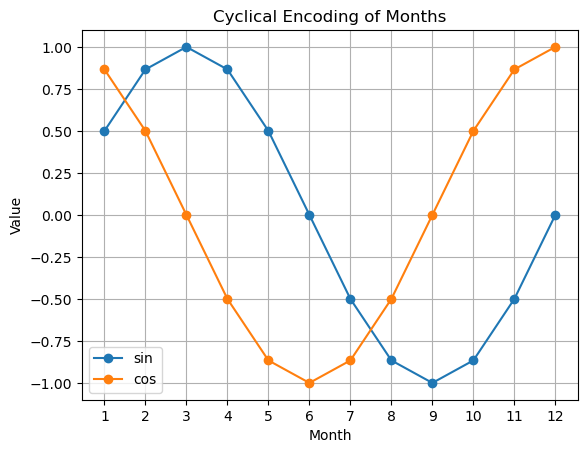

In [44]:
months = np.arange(1, 13)
month_sin = np.sin(2 * np.pi * months / 12)
month_cos = np.cos(2 * np.pi * months / 12)

plt.plot(months, month_sin, marker='o', label='sin')
plt.plot(months, month_cos, marker='o', label='cos')
plt.xticks(months)
plt.title("Cyclical Encoding of Months")
plt.xlabel("Month")
plt.ylabel("Value")
plt.legend()
plt.grid()
plt.show()

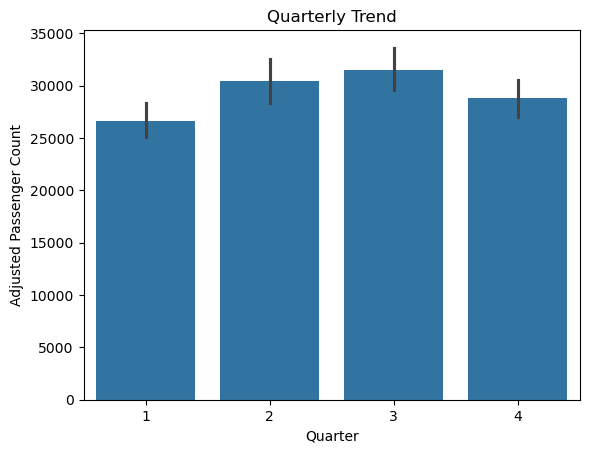

In [45]:
sns.barplot(x='Quarter', y='Adjusted Passenger Count', data=df_fe)
plt.title("Quarterly Trend")
plt.show()

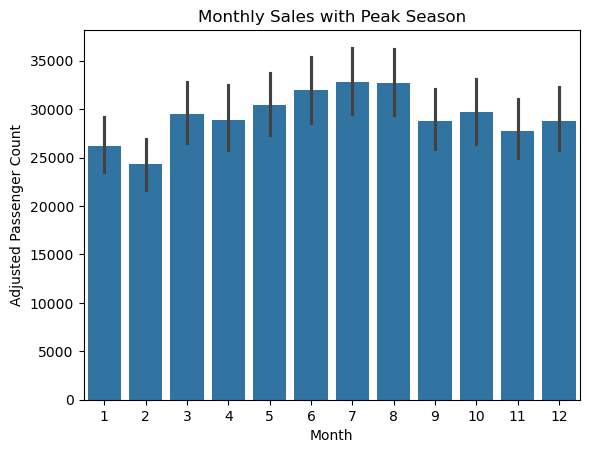

In [46]:
sns.barplot(x='Month', y='Adjusted Passenger Count', data=df_base)
plt.title("Monthly Sales with Peak Season")
plt.show()

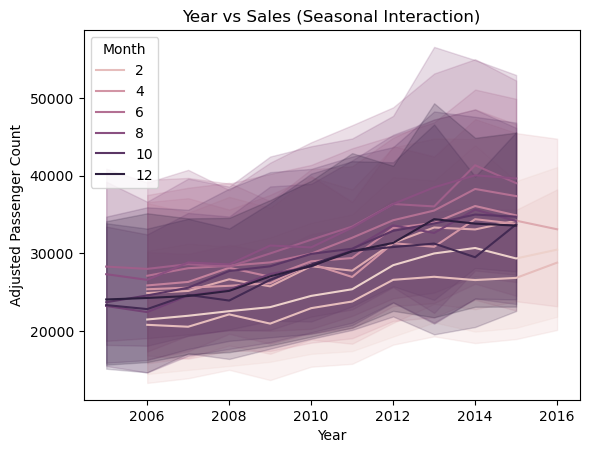

In [47]:
sns.lineplot(x='Year', y='Adjusted Passenger Count', hue='Month', data=df_base)
plt.title("Year vs Sales (Seasonal Interaction)")
plt.show()

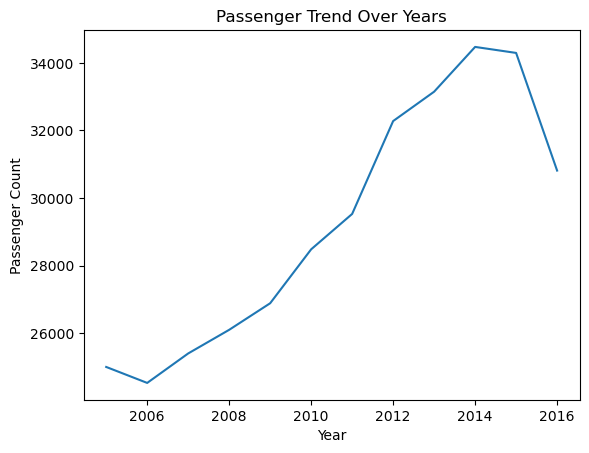

In [48]:
df.groupby('Year')['Adjusted Passenger Count'].mean().plot()
plt.title("Passenger Trend Over Years")
plt.ylabel("Passenger Count")
plt.show()

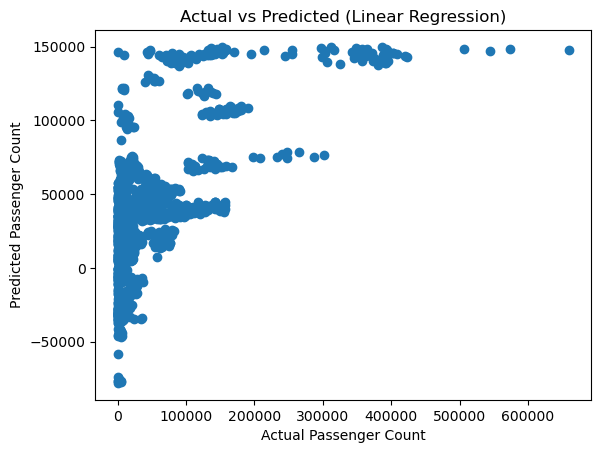

In [51]:
# Regression target
y_reg = df_base['Adjusted Passenger Count']

# Classification target
y_clf = df_base['High_Traffic']
# Regression split
y_train_reg = y_reg.loc[train_idx]
y_test_reg = y_reg.loc[test_idx]

# Classification split
y_train_clf = y_clf.loc[train_idx]
y_test_clf = y_clf.loc[test_idx]
plt.figure()
y_pred_lr = model_base.predict(X_test_base)

plt.scatter(y_test_reg, y_pred_lr)
plt.xlabel("Actual Passenger Count")
plt.ylabel("Predicted Passenger Count")
plt.title("Actual vs Predicted (Linear Regression)")
plt.show()

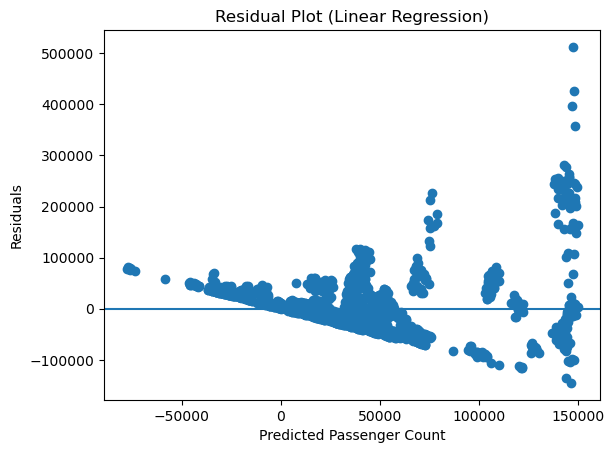

In [52]:
# Predictions from Linear Regression
y_pred_lr = model_base.predict(X_test_base)

# Residuals (Actual - Predicted)
residuals = y_test_reg - y_pred_lr

# Plot
plt.figure()
plt.scatter(y_pred_lr, residuals)

# Horizontal reference line at 0
plt.axhline(0)

plt.xlabel("Predicted Passenger Count")
plt.ylabel("Residuals")
plt.title("Residual Plot (Linear Regression)")
plt.show()

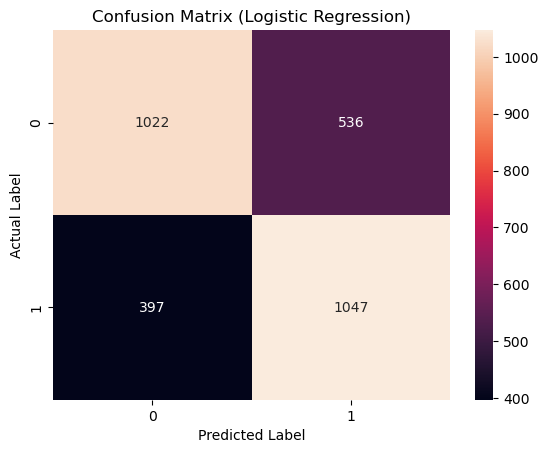

In [53]:
from sklearn.metrics import confusion_matrix
# Predictions from Logistic Regression (use FE model if better)
y_pred_clf = log_model_fe.predict(X_test_fe)

# Confusion Matrix
cm = confusion_matrix(y_test_clf, y_pred_clf)

# Plot
plt.figure()
sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix (Logistic Regression)")
plt.show()